1. Dataset Overview

2. Missing Value Analysis

3. Route Type Analysis

4. Actual Time Analysis

5. OSRM Time Analysis

6. Factor Analysis

7. Facility (Hub) Analysis

8. Corridor Analysis

9. Delay Investigation

10. Data Quality Audit

11. Business Insights

12. Graph Construction Readiness

13. Phase 1 Summary



In [7]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Dataset/delivery_data.csv"
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("COLUMN INFO")
print("="*60)

df.info()

print("\n")

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

display(df.describe(include='all'))

DATASET SHAPE
(144867, 24)


COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          14486

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867,144867,144867,144867,144867,144867,144574,144867,144606,144867,...,144867,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
unique,2,14817,1504,2,14817,1508,1498,1481,1468,26369,...,93180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,training,2018-09-22 04:55:04.835022,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,FTL,trip-153759210483476123,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-21 18:37:09.322207,...,2018-09-24 05:19:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,104858,101,1812,99660,101,23347,23347,15192,15192,81,...,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000


In [9]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

missing = missing.sort_values(
    by='Missing Count',
    ascending=False
)

missing

,Missing Count,Missing %
source_name,293,0.20
destination_name,261,0.18
route_schedule_uuid,0,0.00
data,0,0.00
route_type,0,0.00
trip_uuid,0,0.00
source_center,0,0.00
trip_creation_time,0,0.00
destination_center,0,0.00
od_start_time,0,0.00


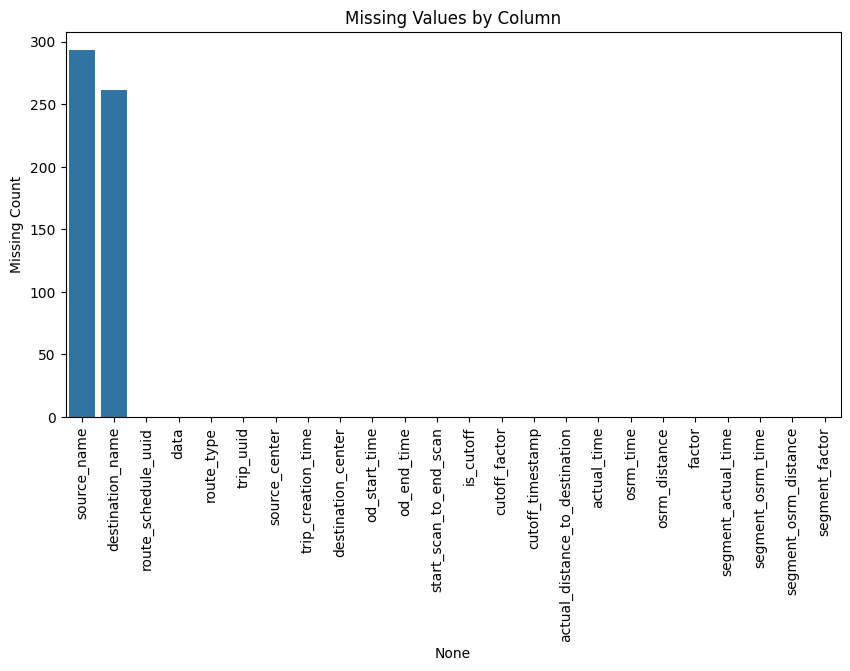

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing['Missing Count']
)

plt.xticks(rotation=90)

plt.title("Missing Values by Column")

plt.show()

In [11]:
route_counts = df['route_type'].value_counts()

route_counts

,count
route_type,
FTL,99660
Carting,45207


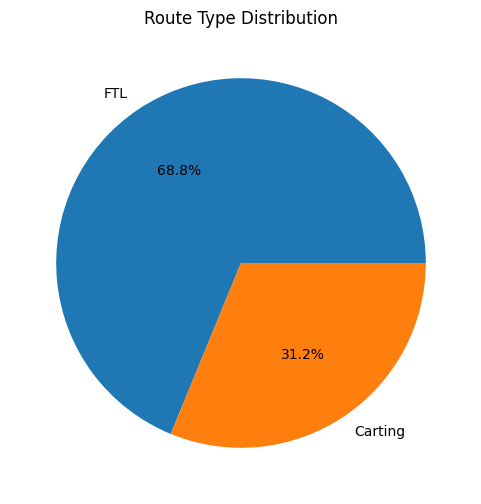

In [12]:
plt.figure(figsize=(6,6))

plt.pie(
    route_counts,
    labels=route_counts.index,
    autopct='%1.1f%%'
)

plt.title("Route Type Distribution")

plt.show()

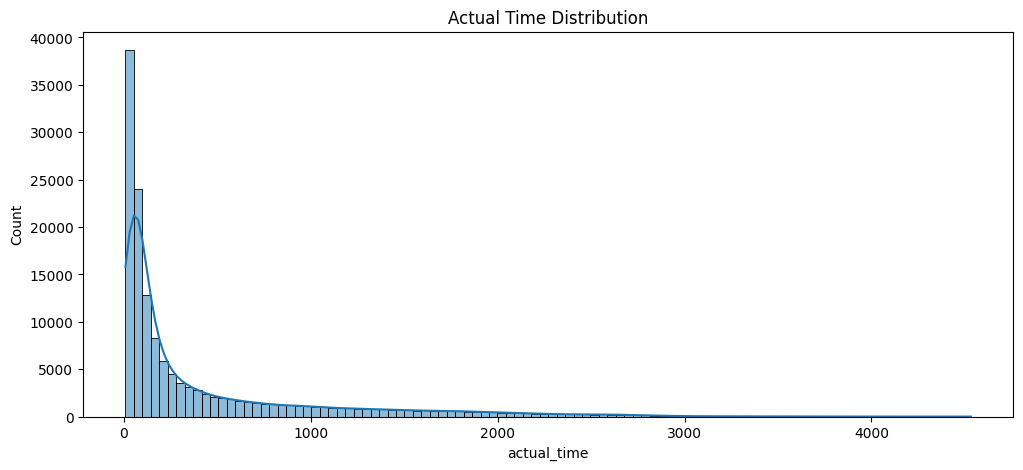

In [13]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['actual_time'],
    bins=100,
    kde=True
)

plt.title("Actual Time Distribution")

plt.show()

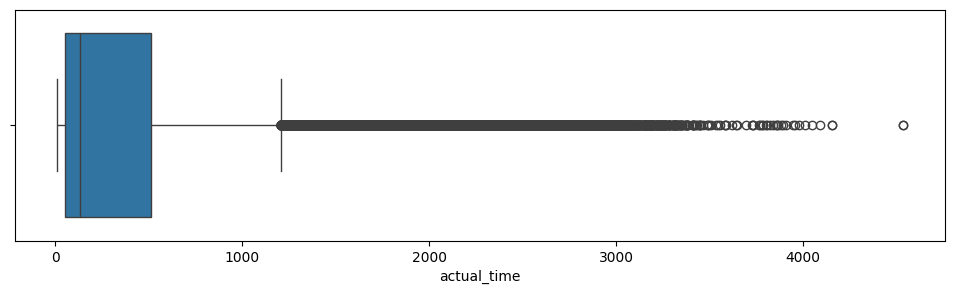

In [14]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df['actual_time']
)

plt.show()

In [15]:
df['actual_time'].describe(
    percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]
)

,actual_time
count,144867.000000
mean,416.927527
std,598.103621
min,9.000000
25%,51.000000
50%,132.000000
75%,513.000000
90%,1325.000000
95%,1823.000000
99%,2599.000000


Business Interpretation
A small number of routes likely create
a disproportionate share of delays.

Potential bottleneck routes exist.

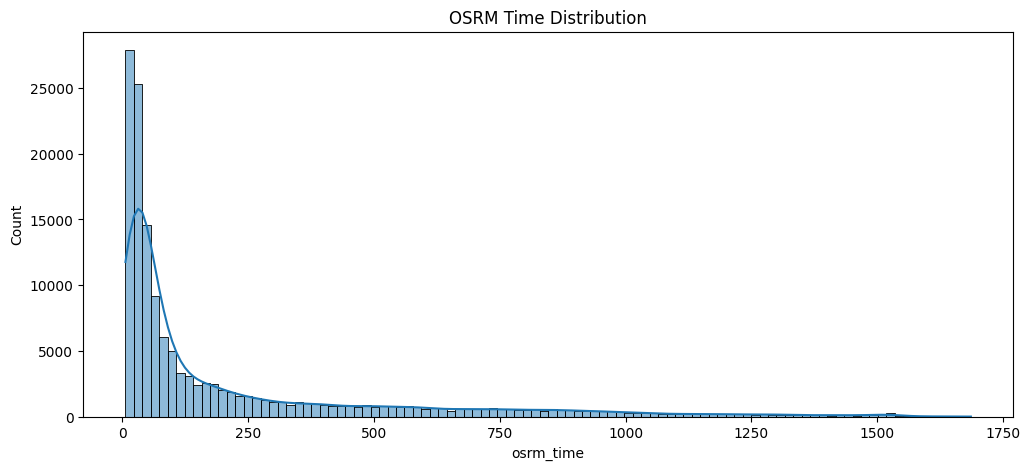

,osrm_time
count,144867.000000
mean,213.868272
std,308.011085
min,6.000000
25%,27.000000
50%,64.000000
75%,257.000000
90%,692.000000
95%,925.000000
99%,1355.000000


In [16]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['osrm_time'],
    bins=100,
    kde=True
)

plt.title("OSRM Time Distribution")

plt.show()

df['osrm_time'].describe(
    percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]
)

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

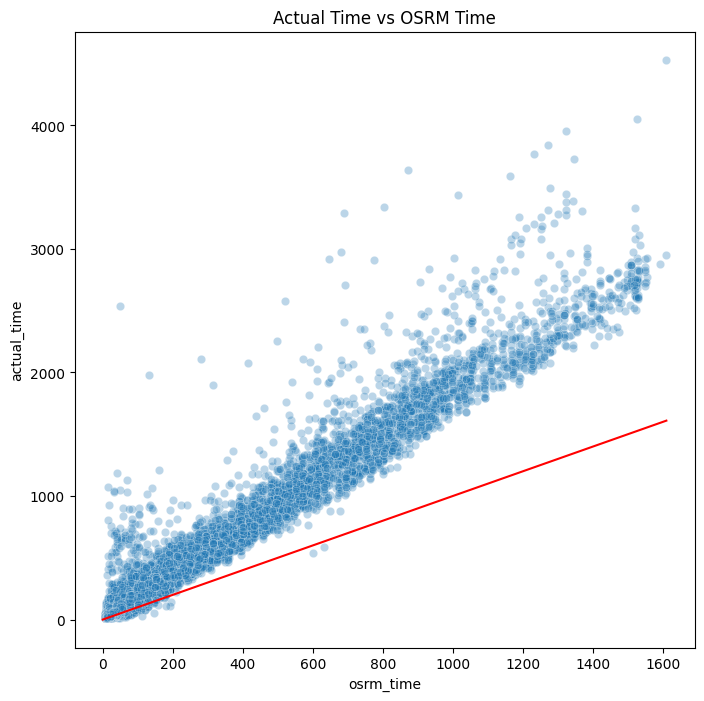

In [17]:
sample = df.sample(
    min(15000,len(df)),
    random_state=42
)

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=sample,
    x='osrm_time',
    y='actual_time',
    alpha=0.3
)

plt.plot(
    [0,sample['osrm_time'].max()],
    [0,sample['osrm_time'].max()],
    color='red'
)

plt.title(
    "Actual Time vs OSRM Time"
)

plt.show()

Above diagonal:

Actual > OSRM

Operational delay exists.

Below diagonal:

OSRM overestimated.

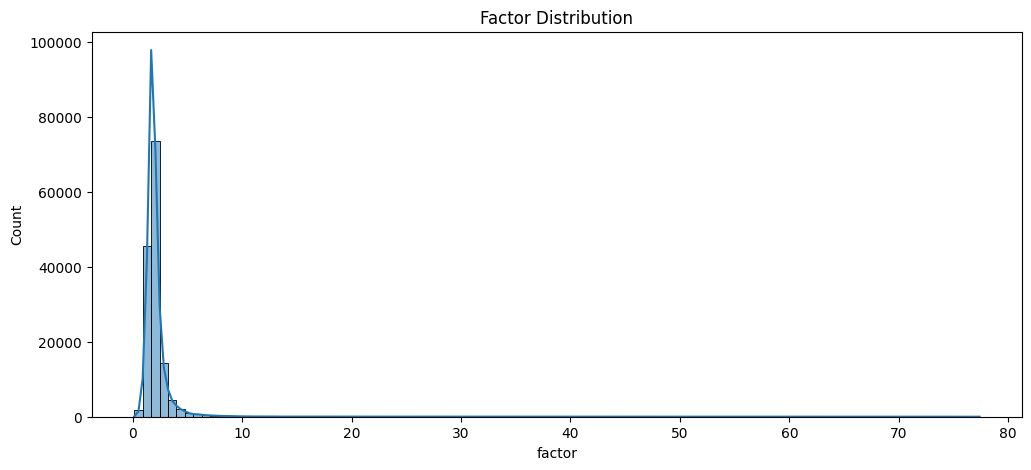

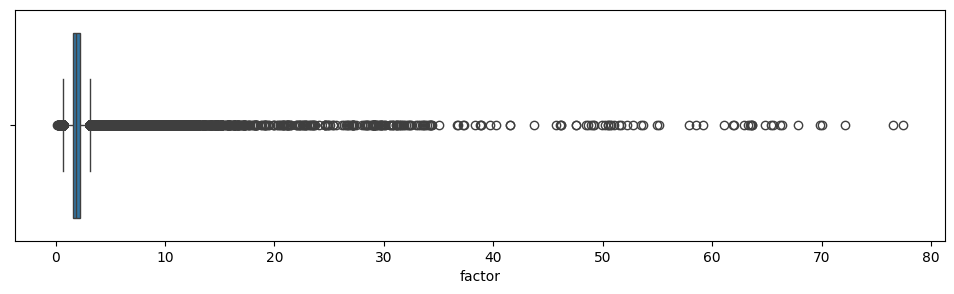

,factor
count,144867.000000
mean,2.120107
std,1.715421
min,0.144000
50%,1.857143
75%,2.213483
90%,2.857143
95%,3.612706
99%,6.958900
max,77.387097


In [18]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['factor'],
    bins=100,
    kde=True
)

plt.title("Factor Distribution")

plt.show()

plt.figure(figsize=(12,3))

sns.boxplot(
    x=df['factor']
)

plt.show()

df['factor'].describe(
    percentiles=[0.5,0.75,0.90,0.95,0.99]
)

In [19]:
calculated_factor = (
    df['actual_time']
    /
    df['osrm_time']
)

error = (
    df['factor']
    -
    calculated_factor
).abs()

error.describe()


,0
count,1.448670e+05
mean,5.586886e-17
std,1.526874e-16
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,7.105427e-15


In [20]:
print((error < 0.001).mean())

1.0


In [21]:
all_facilities = pd.concat([
    df['source_center'],
    df['destination_center']
])

print(
    all_facilities.nunique()
)

1657


In [22]:
# Combine all facilities appearing as source or destination

all_facilities = pd.concat([
    df['source_center'],
    df['destination_center']
])

facility_freq = all_facilities.value_counts()

print("Unique Facilities:", all_facilities.nunique())


Unique Facilities: 1657


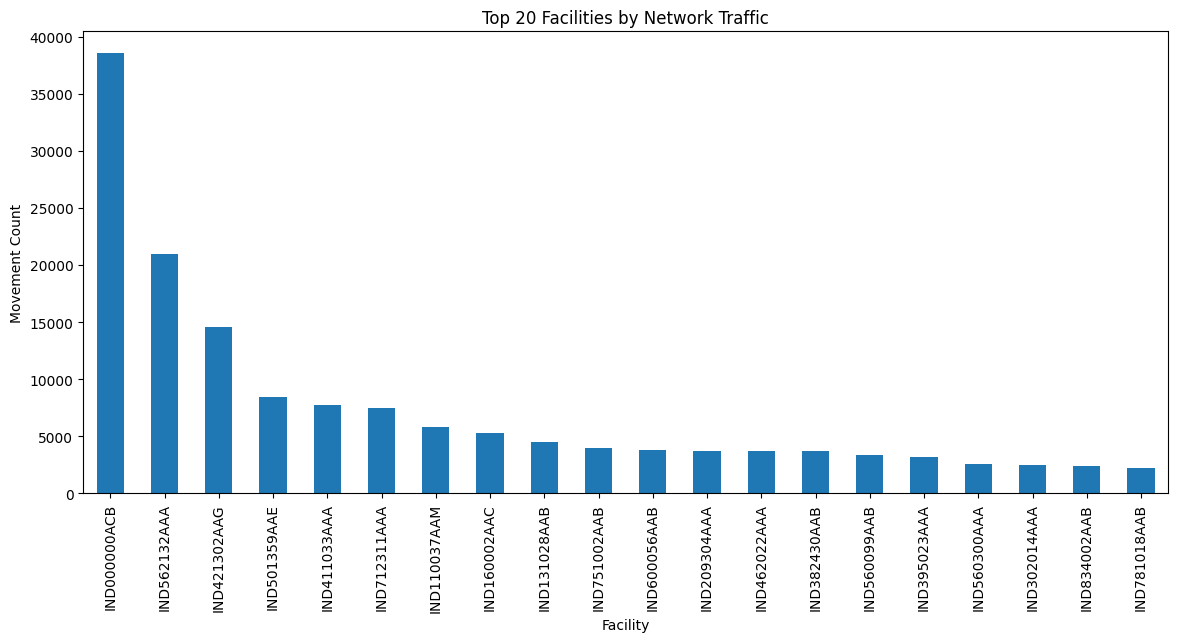

In [23]:
plt.figure(figsize=(14,6))

facility_freq.head(20).plot(
    kind='bar'
)

plt.title("Top 20 Facilities by Network Traffic")
plt.ylabel("Movement Count")
plt.xlabel("Facility")

plt.show()

In [24]:
df['corridor'] = (
    df['source_center'].astype(str)
    +
    " -> "
    +
    df['destination_center'].astype(str)
)

In [25]:
df['corridor'].nunique()

2783

In [26]:
corridor_counts = (
    df['corridor']
    .value_counts()
)

corridor_counts.head(20)

,count
corridor,
IND000000ACB -> IND562132AAA,4976
IND562132AAA -> IND000000ACB,3316
IND000000ACB -> IND712311AAA,2862
IND000000ACB -> IND501359AAE,1639
IND000000ACB -> IND421302AAG,1617
IND421302AAG -> IND000000ACB,1269
IND781018AAB -> IND110037AAM,1137
IND421302AAG -> IND562132AAA,1131
IND000000ACB -> IND411033AAA,1120


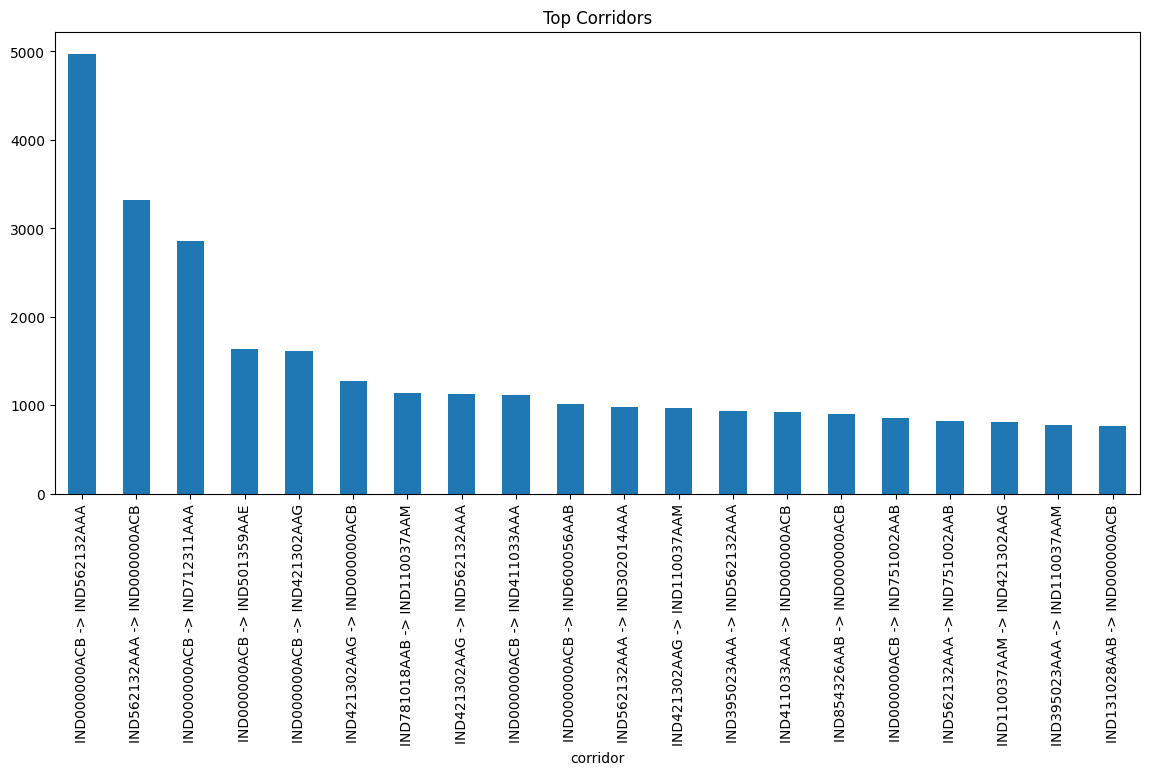

In [27]:
plt.figure(figsize=(14,6))

corridor_counts.head(20).plot(
    kind='bar'
)

plt.title(
    "Top Corridors"
)

plt.show()

In [28]:
corridor_delay = (
    df.groupby('corridor')['factor']
      .mean()
      .sort_values(
          ascending=False
      )
)

corridor_delay.head(20)

,factor
corridor,
IND212402AAA -> IND211002AAB,34.851053
IND785634AAA -> IND785001AAA,31.108333
IND842003AAB -> IND482002AAA,28.531250
IND416606AAA -> IND416510AAA,23.556107
IND395006AAA -> IND395023AAD,23.502083
IND424304AAC -> IND424006AAA,22.313663
IND208012AAA -> IND209304AAA,22.183624
IND211008AAA -> IND211002AAB,20.189616
IND722140AAA -> IND723130AAA,19.130435


In [29]:
source_delay = (
    df.groupby('source_center')['factor']
      .mean()
      .sort_values(
          ascending=False
      )
)

source_delay.head(20)

,factor
source_center,
IND212402AAA,34.851053
IND785634AAA,31.108333
IND416606AAA,23.556107
IND395006AAA,23.502083
IND208012AAA,22.183624
IND211008AAA,20.189616
IND121002AAA,19.083333
IND151103AAA,15.672365
IND743270AAA,15.364719


In [30]:
destination_delay = (
    df.groupby('destination_center')['factor']
      .mean()
      .sort_values(
          ascending=False
      )
)

destination_delay.head(20)

,factor
destination_center,
IND482002AAA,28.531250
IND416510AAA,18.641965
IND282005AAA,18.437028
IND221401AAA,16.714286
IND490023AAA,14.409836
IND232101AAB,10.510856
IND211002AAB,9.720381
IND000000AFS,9.416667
IND400037AAA,9.000000


In [31]:
df['segment_factor'].describe()

,segment_factor
count,144867.000000
mean,2.218368
std,4.847530
min,-23.444444
25%,1.347826
50%,1.684211
75%,2.250000
max,574.250000


In [32]:
df[
    df['segment_factor'] < 0
].shape


(2365, 25)

In [33]:
df[
    df['segment_factor'] < 0
][[
    'segment_actual_time',
    'segment_osrm_time',
    'segment_factor'
]].head()



,segment_actual_time,segment_osrm_time,segment_factor
47,2.0,0.0,-1.0
54,0.0,0.0,-1.0
90,2.0,0.0,-1.0
164,0.0,0.0,-1.0
224,0.0,0.0,-1.0


In [34]:
df[
    df['segment_osrm_time'] < 1
].shape

(2347, 25)

In [35]:
df.sort_values(
    by='segment_factor',
    ascending=False
).head(20)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,corridor
5587,training,2018-09-22 11:28:06.474852,thanos::sroute:eb6f76d9-015d-4e25-bb5e-1469422...,Carting,trip-153761568647456368,IND271001AAA,Gonda_KotwaliN_D (Uttar Pradesh),IND271201AAA,Balrampur_PBRDDPP_D (Uttar Pradesh),2018-09-22 11:28:06.474852,...,33.854389,2399.0,31.0,42.0020,77.387097,2297.0,4.0,3.8825,574.250000,IND271001AAA -> IND271201AAA
15601,training,2018-09-24 09:42:45.961375,thanos::sroute:a78a08b2-ba1f-4d5a-837c-096fee6...,Carting,trip-153778216596113868,IND452001AAC,Jalgaon_DC (Maharashtra),IND425201AAA,Bhusawal_Samarth_D (Maharashtra),2018-09-24 09:42:45.961375,...,21.458701,1195.0,18.0,26.6747,66.388889,1117.0,2.0,1.8177,558.500000,IND452001AAC -> IND425201AAA
2081,training,2018-09-24 09:44:21.640187,thanos::sroute:c2773681-72f7-4483-8942-e031105...,FTL,trip-153778226163995868,IND580028AAA,Hubli_Adargchi_IP (Karnataka),IND580002AAA,Dharwad_Dc (Karnataka),2018-09-24 09:44:21.640187,...,23.185948,579.0,22.0,27.5155,26.318182,493.0,1.0,0.9414,493.000000,IND580028AAA -> IND580002AAA
35646,training,2018-09-17 09:26:39.998658,thanos::sroute:a78a08b2-ba1f-4d5a-837c-096fee6...,Carting,trip-153717640309053191,IND452001AAC,Jalgaon_DC (Maharashtra),IND425201AAA,Bhusawal_Samarth_D (Maharashtra),2018-09-17 09:26:39.998658,...,20.786734,1138.0,18.0,25.9898,63.222222,1086.0,3.0,5.1009,362.000000,IND452001AAC -> IND425201AAA
104982,training,2018-09-15 10:46:36.228538,thanos::sroute:eb6f76d9-015d-4e25-bb5e-1469422...,Carting,trip-153700839622813110,IND271001AAA,Gonda_KotwaliN_D (Uttar Pradesh),IND271210AAA,Tulsipur_Central_DPP_1 (Uttar Pradesh),2018-09-15 10:46:36.228538,...,61.244922,2536.0,50.0,70.6944,50.720000,2408.0,8.0,10.9888,301.000000,IND271001AAA -> IND271210AAA
78512,training,2018-09-19 02:48:27.012436,thanos::sroute:d5ad71ae-d763-4cdb-af53-1c78952...,Carting,trip-153732530701217634,IND283122AAB,Kirauli_AchneraRD_D (Uttar Pradesh),IND282005AAA,Agra (Uttar Pradesh),2018-09-19 05:48:13.025261,...,21.012835,401.0,24.0,29.5020,16.708333,289.0,1.0,1.3975,289.000000,IND283122AAB -> IND282005AAA
29375,test,2018-09-27 23:45:14.576688,thanos::sroute:02de57bd-bcf5-4c26-a02e-38f1a60...,Carting,trip-153809191457632409,IND208012AAA,Kanpur_Central_D_7 (Uttar Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-28 03:38:32.837657,...,17.774011,940.0,18.0,20.1819,52.222222,288.0,1.0,1.4874,288.000000,IND208012AAA -> IND209304AAA
58911,training,2018-09-12 12:49:25.626881,thanos::sroute:873bc037-283e-46a2-8135-5128fa2...,Carting,trip-153675656562660066,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND122001AAA,GGN_DPC (Haryana),2018-09-12 12:49:25.626881,...,29.612153,297.0,35.0,35.9510,8.485714,241.0,1.0,1.0673,241.000000,IND000000ACB -> IND122001AAA
130915,test,2018-09-27 15:13:23.453630,thanos::sroute:abd1259c-021b-45f0-9c57-f28f118...,Carting,trip-153806120345334308,IND560058AAD,Bengaluru_Peenya_L (Karnataka),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),2018-09-27 15:13:23.453630,...,10.765532,403.0,23.0,15.3497,17.521739,385.0,2.0,1.5556,192.500000,IND560058AAD -> IND562132AAA
88330,test,2018-10-01 11:27:39.027619,thanos::sroute:911f6f84-2799-473b-8702-b5e3676...,FTL,trip-153839325902727888,IND382430AAB,Ahmedabad_East_H_1 (Gujarat),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-10-01 11:27:39.027619,...,735.316006,1811.0,630.0,875.6380,2.874603,755.0,4.0,6.4516,188.750000,IND382430AAB -> IND000000ACB


In [36]:
df.groupby('route_type')[[
    'actual_time',
    'osrm_time',
    'factor'
]].mean()

,actual_time,osrm_time,factor
route_type,,,
Carting,70.639082,30.450483,2.409842
FTL,574.008218,297.068834,1.988680


In [37]:
all_facilities.nunique()

1657

In [38]:
df['corridor'].nunique()

2783

In [39]:
nodes = all_facilities.nunique()
edges = df['corridor'].nunique()

density = edges / (nodes*(nodes-1))

density

0.0010142157848856703

In [40]:
route_summary = (
    df.groupby('route_type')[[
        'actual_time',
        'osrm_time',
        'factor'
    ]]
    .agg(['mean','median'])
)

route_summary

actual_time          osrm_time           factor          
                  mean median        mean median      mean    median
route_type                                                          
Carting      70.639082   48.0   30.450483   24.0  2.409842  1.916667
FTL         574.008218  279.0  297.068834  145.0  1.988680  1.844679

In [41]:
route_business = (
    df.groupby('route_type')[[
        'actual_time',
        'osrm_time',
        'factor'
    ]]
    .mean()
    .round(2)
)

route_business

,actual_time,osrm_time,factor
route_type,,,
Carting,70.64,30.45,2.41
FTL,574.01,297.07,1.99


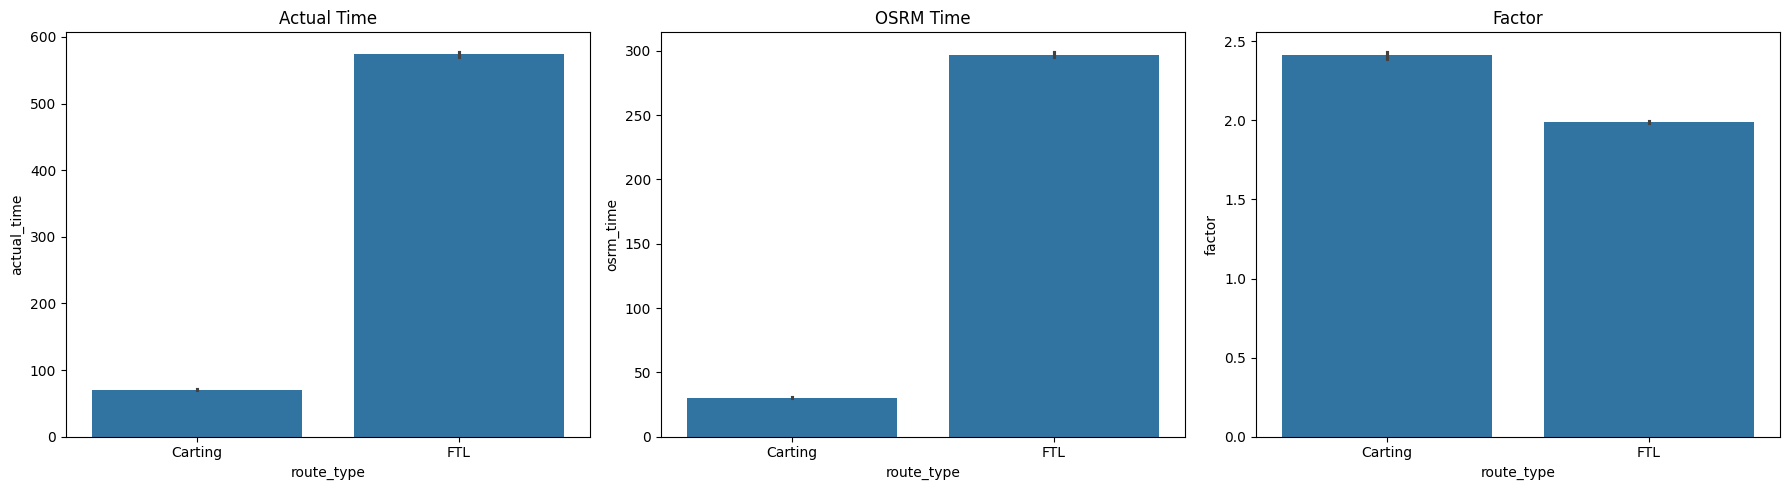

In [42]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.barplot(
    data=df,
    x='route_type',
    y='actual_time',
    ax=axes[0]
)

axes[0].set_title("Actual Time")

sns.barplot(
    data=df,
    x='route_type',
    y='osrm_time',
    ax=axes[1]
)

axes[1].set_title("OSRM Time")

sns.barplot(
    data=df,
    x='route_type',
    y='factor',
    ax=axes[2]
)

axes[2].set_title("Factor")

plt.tight_layout()
plt.show()

In [43]:
df['segment_factor'].describe(
    percentiles=[0.5,0.75,0.90,0.95,0.99]
)

,segment_factor
count,144867.000000
mean,2.218368
std,4.847530
min,-23.444444
50%,1.684211
75%,2.250000
90%,3.277778
95%,4.428571
99%,11.500000
max,574.250000


In [44]:
negative_segment_factor = (
    df['segment_factor'] < 0
).sum()

negative_segment_factor

np.int64(2365)

In [45]:
tiny_osrm = (
    df['segment_osrm_time'] < 1
).sum()

tiny_osrm

np.int64(2347)

In [46]:
df[
    [
        'segment_actual_time',
        'segment_osrm_time',
        'segment_factor'
    ]
].sort_values(
    by='segment_factor',
    ascending=False
).head(20)

,segment_actual_time,segment_osrm_time,segment_factor
5587,2297.0,4.0,574.250000
15601,1117.0,2.0,558.500000
2081,493.0,1.0,493.000000
35646,1086.0,3.0,362.000000
104982,2408.0,8.0,301.000000
78512,289.0,1.0,289.000000
29375,288.0,1.0,288.000000
58911,241.0,1.0,241.000000
130915,385.0,2.0,192.500000
88330,755.0,4.0,188.750000


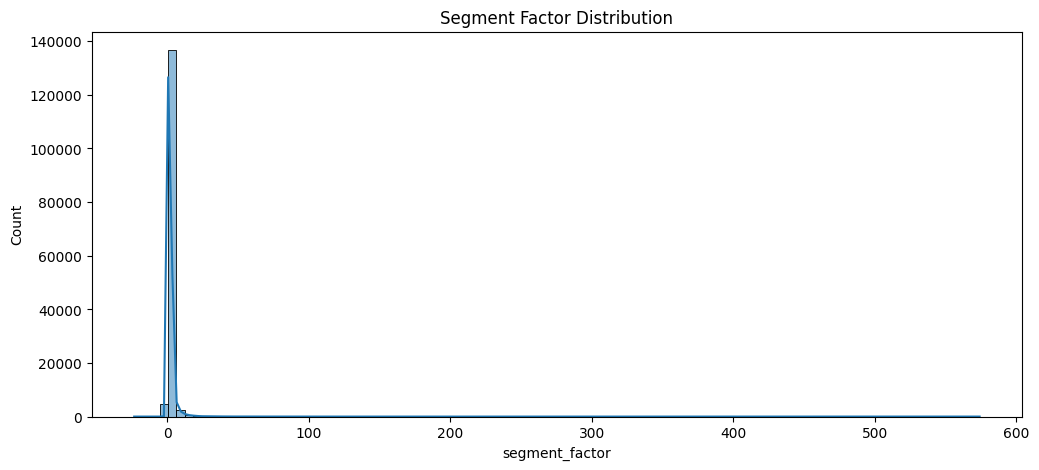

In [47]:
plt.figure(figsize=(12,5))

sns.histplot(
    df['segment_factor'],
    bins=100,
    kde=True
)

plt.title("Segment Factor Distribution")

plt.show()

In [48]:
corridor_counts = (
    df['corridor']
    .value_counts()
)

In [49]:
corridor_counts.describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99
    ]
)

,count
count,2783.000000
mean,52.054258
std,167.682747
min,1.000000
50%,20.000000
75%,44.000000
90%,96.000000
95%,168.800000
99%,671.540000
max,4976.000000


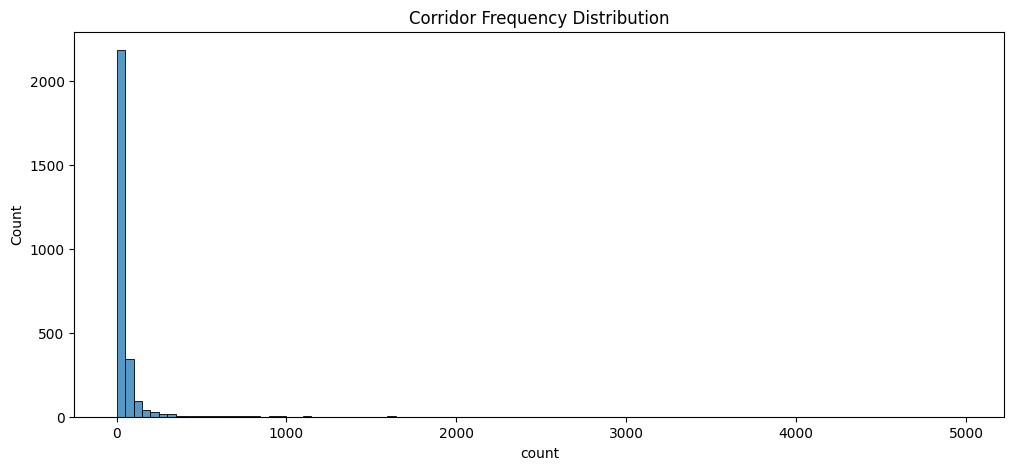

In [50]:
plt.figure(figsize=(12,5))

sns.histplot(
    corridor_counts,
    bins=100
)

plt.title(
    "Corridor Frequency Distribution"
)

plt.show()

In [51]:
valid_corridors = corridor_counts[
    corridor_counts >= 30
].index

In [52]:
corridor_delay_filtered = (
    df[
        df['corridor'].isin(
            valid_corridors
        )
    ]
    .groupby('corridor')['factor']
    .mean()
    .sort_values(
        ascending=False
    )
)

corridor_delay_filtered.head(20)

,factor
corridor,
IND212402AAA -> IND211002AAB,34.851053
IND416606AAA -> IND416510AAA,23.556107
IND208012AAA -> IND209304AAA,22.183624
IND847226AAA -> IND842001AAA,9.438599
IND847404AAB -> IND842001AAA,8.089730
IND401602AAA -> IND401501AAA,7.653921
IND175015AAA -> IND174001AAA,6.754443
IND829121AAA -> IND834002AAB,6.671639
IND798601AAA -> IND785001AAA,6.049938
